# Disaster Tweets Classification: TF-IDF + Logistic Regression

## Overview
This notebook implements a classical machine learning approach to binary classification of disaster-related tweets using TF-IDF vectorization and Logistic Regression.

**Dataset**: [Kaggle NLP Getting Started - Real or Not? NLP with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?selb)

**Task**: Binary classification to determine if a tweet is about a real disaster (1) or not (0)

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Dataset Analysis and Preprocessing

### 2.1 Load and Explore Data

In [ ]:
df = pd.read_csv('train_prepared.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['target'].value_counts())
print("\nClass balance:")
print(df['target'].value_counts(normalize=True))

Dataset shape: (6960, 4)

First few rows:
   id keyword                                               text  target
0   1     NaN  Our Deeds are the Reason of this #earthquake M...       1
1   4     NaN             Forest fire near La Ronge Sask. Canada       1
2   5     NaN  All residents asked to 'shelter in place' are ...       1
3   6     NaN  13,000 people receive #wildfires evacuation or...       1
4   7     NaN  Just got sent this photo from Ruby #Alaska as ...       1
5   8     NaN  #RockyFire Update => California Hwy. 20 closed...       1
6  10     NaN  #flood #disaster Heavy rain causes flash flood...       1
7  13     NaN  I'm on top of the hill and I can see a fire in...       1
8  14     NaN  There's an emergency evacuation happening now ...       1
9  15     NaN  I'm afraid that the tornado is coming to our a...       1

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6960 entries, 0 to 6959
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtyp

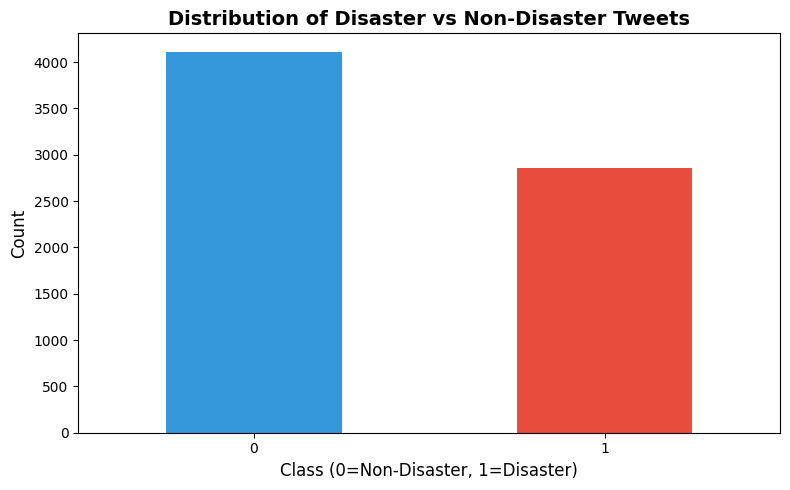

In [ ]:
plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribution of Disaster vs Non-Disaster Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Class (0=Non-Disaster, 1=Disaster)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Example Tweets from Dataset

In [ ]:
print("DISASTER TWEETS (target=1):")

for i, tweet in enumerate(df[df['target'] == 1]['text'].head(5), 1):
    print(f"{i}. {tweet}")
    print()

print("NON-DISASTER TWEETS (target=0):")

for i, tweet in enumerate(df[df['target'] == 0]['text'].head(5), 1):
    print(f"{i}. {tweet}")
    print()

DISASTER TWEETS (target=1):
1. Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

2. Forest fire near La Ronge Sask. Canada

3. All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected

4. 13,000 people receive #wildfires evacuation orders in California 

5. Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 

NON-DISASTER TWEETS (target=0):
1. What's up man?

2. I love fruits

3. Summer is lovely

4. My car is so fast

5. What a goooooooaaaaaal!!!!!!



### 2.3 Data Cleaning

We'll preprocess the tweets by:
- Removing URLs (links don't contribute meaningful semantic information)
- Handling missing values
- Removing duplicates

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = text.replace('<LINK>', '').replace('<MENTION>', '')
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = ' '.join(text.split())
    return text.strip()

print("Original dataset size:", len(df))
df['text_clean'] = df['text'].apply(clean_text)

df = df[df['text_clean'].str.len() > 0]
print("After removing empty texts:", len(df))

initial_size = len(df)
df = df.drop_duplicates(subset=['text_clean'], keep='first')
print(f"After removing duplicates: {len(df)} (removed {initial_size - len(df)} duplicates)")
df = df.reset_index(drop=True)

print("\nFinal dataset shape:", df.shape)
print("Final class distribution:")
print(df['target'].value_counts())

Original dataset size: 6960
After removing empty texts: 6960
After removing duplicates: 6921 (removed 39 duplicates)

Final dataset shape: (6921, 5)
Final class distribution:
target
0    4086
1    2835
Name: count, dtype: int64


## 3. TF-IDF Vectorization

### 3.1 Understanding TF-IDF

**TF-IDF (Term Frequency-Inverse Document Frequency)** is a numerical statistic that reflects how important a word is to a document in a collection of documents.

**Components:**

1. **Term Frequency (TF)**: How frequently a term appears in a document
   $$TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

2. **Inverse Document Frequency (IDF)**: How important a term is across all documents
   $$IDF(t, D) = \log\left(\frac{\text{Total number of documents}}{\text{Number of documents containing term } t}\right)$$

3. **TF-IDF Score**: Combination of both
   $$\text{TF-IDF}(t, d, D) = TF(t, d) \times IDF(t, D)$$

**Key Properties:**
- Words that appear frequently in a document but rarely across documents get high scores (discriminative terms)
- Common words ("the", "is", "a") that appear in many documents get low scores
- Results in a sparse matrix representation where each tweet is a vector of TF-IDF scores

### 3.2 TF-IDF Hyperparameters

**Hyperparameters explained:**

- `max_features=5000`: Limit vocabulary to top 5000 most frequent terms (reduces dimensionality, prevents overfitting)
- `ngram_range=(1, 2)`: Use both unigrams (single words) and bigrams (two-word phrases)
  - Example: "forest fire" as bigram captures more context than separate "forest" and "fire"
- `min_df=2`: Ignore terms appearing in fewer than 2 documents (filters out typos and rare terms)
- `max_df=0.8`: Ignore terms appearing in more than 80% of documents (filters out common words)
- `sublinear_tf=True`: Apply sublinear scaling to term frequency (uses 1 + log(tf) instead of tf)
- `strip_accents='unicode'`: Remove accents from characters
- `analyzer='word'`: Tokenize by word boundaries
- `token_pattern`: Pattern to identify tokens (default: words of 2+ characters)

In [ ]:
X = df['text_clean'].values
y = df['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  
)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nValidation set class distribution:")
print(pd.Series(y_val).value_counts())

Training set size: 5536
Validation set size: 1385

Training set class distribution:
0    3268
1    2268
Name: count, dtype: int64

Validation set class distribution:
0    818
1    567
Name: count, dtype: int64


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,      # Limit vocabulary size
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=2,               # Ignore rare terms
    max_df=0.8,             # Ignore very common terms
    sublinear_tf=True,      # Apply sublinear tf scaling
    strip_accents='unicode', # Normalize accents
    analyzer='word',        # Tokenize by words
    token_pattern=r'\w{2,}', # Words of 2+ characters (filters out single letters)
    stop_words='english'    # Remove common English stop words
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

print(f"Training set TF-IDF shape: {X_train_tfidf.shape}")
print(f"Validation set TF-IDF shape: {X_val_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Training set TF-IDF shape: (5536, 5000)
Validation set TF-IDF shape: (1385, 5000)
Vocabulary size: 5000
Sparsity: 99.86%


### 3.3 Top Features by TF-IDF Score

Top 20 features by average TF-IDF score:
        feature  avg_tfidf
2521       like   0.011605
2368       just   0.010567
1318        don   0.006544
3506     people   0.006315
3175        new   0.006105
1525  emergency   0.005952
3198       news   0.005393
2634       love   0.005341
4733      video   0.005194
663     burning   0.005123
1063        day   0.005117
4333      storm   0.004966
1258   disaster   0.004934
2421       know   0.004873
4533       time   0.004797
1962        got   0.004714
2726        man   0.004496
1950      going   0.004481
571        body   0.004456
3590     police   0.004360


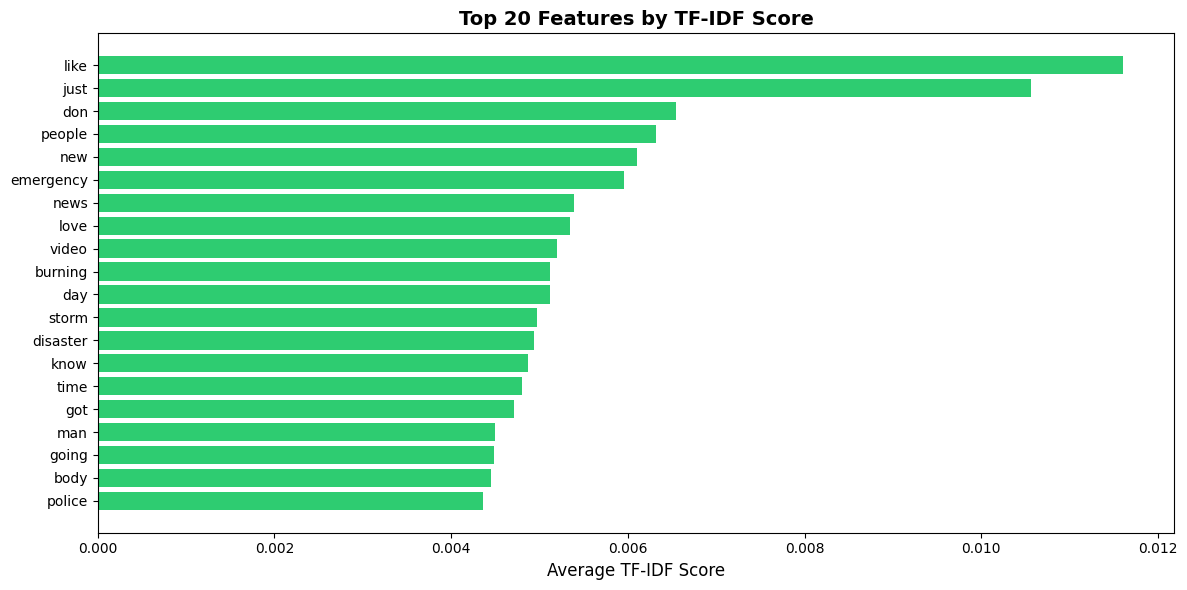

In [ ]:
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X_train_tfidf.toarray()
avg_tfidf = tfidf_scores.mean(axis=0)

feature_scores = pd.DataFrame({
    'feature': feature_names,
    'avg_tfidf': avg_tfidf
}).sort_values('avg_tfidf', ascending=False)

print("Top 20 features by average TF-IDF score:")
print(feature_scores.head(20))

plt.figure(figsize=(12, 6))
top_features = feature_scores.head(20)
plt.barh(range(len(top_features)), top_features['avg_tfidf'], color='#2ecc71')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.title('Top 20 Features by TF-IDF Score', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Logistic Regression Model

### 4.1 Understanding Logistic Regression

**Logistic Regression** is a linear model for binary classification that predicts the probability of an instance belonging to a particular class.

**Model Architecture:**

1. **Linear Combination**: $$z = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n = w^Tx$$
   - Where $w$ are the learned weights and $x$ are the input features (TF-IDF vectors)

2. **Sigmoid Function**: $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
   - Transforms linear output to probability between 0 and 1

3. **Prediction**: $$P(y=1|x) = \sigma(w^Tx)$$
   - If $P(y=1|x) \geq 0.5$: predict class 1 (disaster)
   - If $P(y=1|x) < 0.5$: predict class 0 (non-disaster)

**Loss Function (Binary Cross-Entropy):**
$$L(w) = -\frac{1}{N}\sum_{i=1}^{N}[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$

**Training Process:**
- Uses optimization algorithms (e.g., L-BFGS, SAG) to minimize the loss function
- Finds optimal weights that best separate the two classes
- L2 regularization prevents overfitting by penalizing large weights

**Input/Output:**
- **Input**: TF-IDF vectors (sparse matrix of shape [n_samples, n_features])
- **Output**: Class predictions (0 or 1) or probability scores

**Reference:**
- Das, M., & Chakraborty, S. (2023). "A Comparative Study on TF-IDF feature Weighting Method and its Analysis using Unstructured Dataset." 

### 4.2 Model Hyperparameters

**Hyperparameters explained:**

- `max_iter=1000`: Maximum number of iterations for the solver to converge
- `random_state=42`: Seed for reproducibility
- `class_weight='balanced'`: Automatically adjusts weights inversely proportional to class frequencies
  - Useful for imbalanced datasets to prevent bias toward majority class
  - Formula: $w_j = \frac{n_{samples}}{n_{classes} \times n_{samples_j}}$
- `solver='lbfgs'`: Optimization algorithm (Limited-memory BFGS, efficient for small datasets)
- `C=1.0`: Inverse of regularization strength (smaller values = stronger regularization)

In [ ]:
model = LogisticRegression(
    max_iter=1000,           # Number of iterations
    random_state=RANDOM_STATE,
    class_weight='balanced',  # Handle class imbalance
    solver='lbfgs',          # Optimization algorithm
    C=1.0,                   # Regularization strength
    verbose=1                # Show convergence messages
)

print("Training Logistic Regression model...")
model.fit(X_train_tfidf, y_train)
print("Training complete!")

Training Logistic Regression model...
Training complete!


### 4.3 Model Interpretation: Feature Importance

In [ ]:
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 15 features predicting DISASTER (positive coefficients):")
print(feature_importance.nlargest(15, 'coefficient')[['feature', 'coefficient']])
print("\nTop 15 features predicting NON-DISASTER (negative coefficients):")
print(feature_importance.nsmallest(15, 'coefficient')[['feature', 'coefficient']])

Top 15 features predicting DISASTER (positive coefficients):
         feature  coefficient
2130   hiroshima     3.215973
692   california     2.827742
1781       fires     2.674541
4856    wildfire     2.507334
4333       storm     2.486218
655    buildings     2.472270
2400      killed     2.324481
3148        near     2.321373
3590      police     2.135170
1816      floods     1.981775
1447  earthquake     1.963348
1842      forest     1.904310
2343       japan     1.897306
4373     suicide     1.887083
1395     drought     1.789800

Top 15 features predicting NON-DISASTER (negative coefficients):
          feature  coefficient
2634         love    -1.981883
3175          new    -1.970589
4929      wrecked    -1.669080
2497          let    -1.571348
543          blew    -1.562840
4231         song    -1.549446
3952         ruin    -1.519481
544        blight    -1.516176
3252   nowplaying    -1.480459
1504  electrocute    -1.462693
2368         just    -1.457824
555        bloody    

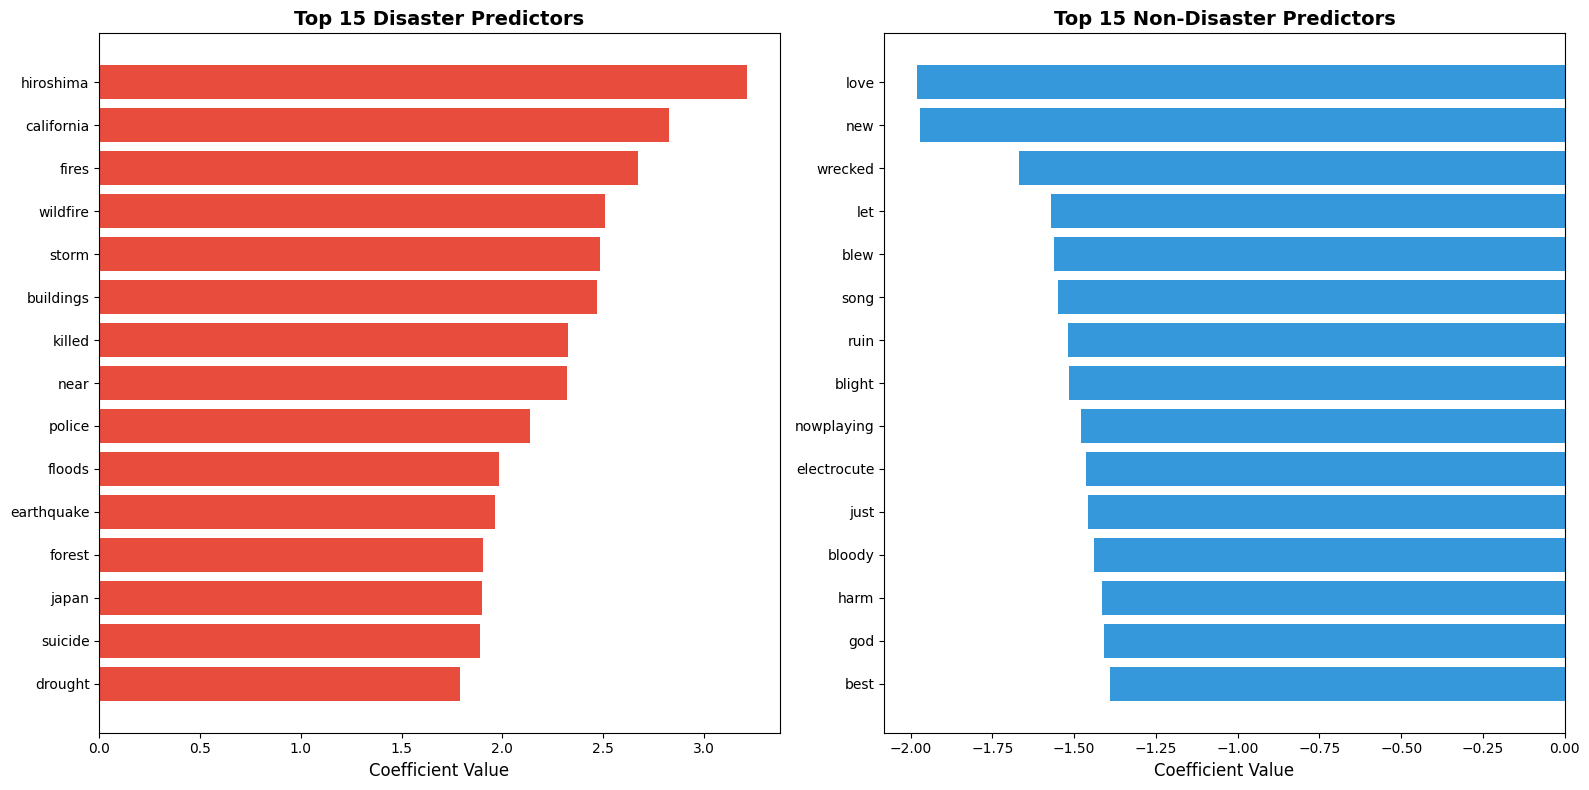

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top disaster predictors
top_disaster = feature_importance.nlargest(15, 'coefficient')
axes[0].barh(range(len(top_disaster)), top_disaster['coefficient'], color='#e74c3c')
axes[0].set_yticks(range(len(top_disaster)))
axes[0].set_yticklabels(top_disaster['feature'])
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top 15 Disaster Predictors', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Top non-disaster predictors
top_non_disaster = feature_importance.nsmallest(15, 'coefficient')
axes[1].barh(range(len(top_non_disaster)), top_non_disaster['coefficient'], color='#3498db')
axes[1].set_yticks(range(len(top_non_disaster)))
axes[1].set_yticklabels(top_non_disaster['feature'])
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Top 15 Non-Disaster Predictors', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Model Evaluation

### 5.1 Metrics Explanation

**Evaluation Metrics:**

1. **Accuracy**: Overall correctness
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

2. **Precision**: Of all positive predictions, how many were correct?
   $$\text{Precision} = \frac{TP}{TP + FP}$$
   - Important when false positives are costly

3. **Recall (Sensitivity)**: Of all actual positives, how many did we identify?
   $$\text{Recall} = \frac{TP}{TP + FN}$$
   - Important when false negatives are costly (e.g., missing real disasters)

4. **F1-Score**: Harmonic mean of precision and recall
   $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
   - Balances precision and recall

Where:
- TP = True Positives (correctly predicted disaster)
- TN = True Negatives (correctly predicted non-disaster)
- FP = False Positives (predicted disaster, was non-disaster)
- FN = False Negatives (predicted non-disaster, was disaster)

In [ ]:
y_pred = model.predict(X_val_tfidf)
y_pred_proba = model.predict_proba(X_val_tfidf)[:, 1]  # Probability of class 1

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)


print("VALIDATION SET RESULTS")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


print("\nDetailed Classification Report:")
print(classification_report(y_val, y_pred, target_names=['Non-Disaster', 'Disaster']))

VALIDATION SET RESULTS
Accuracy:  0.7877
Precision: 0.7382
Recall:    0.7460
F1-Score:  0.7421

Detailed Classification Report:
              precision    recall  f1-score   support

Non-Disaster       0.82      0.82      0.82       818
    Disaster       0.74      0.75      0.74       567

    accuracy                           0.79      1385
   macro avg       0.78      0.78      0.78      1385
weighted avg       0.79      0.79      0.79      1385



### 5.2 Confusion Matrix

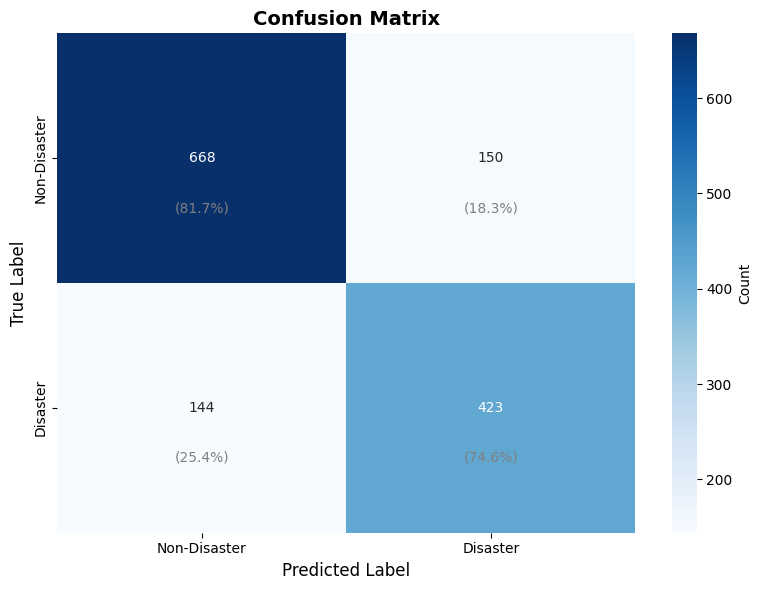


True Negatives:  668
False Positives: 150
False Negatives: 144
True Positives:  423


In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Disaster', 'Disaster'],
            yticklabels=['Non-Disaster', 'Disaster'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

## 6. Multiple Training Runs for Consistency Analysis

To ensure our results are robust and not due to random chance, we perform multiple training runs with different random seeds.

In [ ]:
n_runs = 5
results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print("Performing multiple training runs...\n")
for i in range(n_runs):
    seed = RANDOM_STATE + i
    print(f"Run {i+1}/{n_runs} (seed={seed})...")
    
    # Split data with different seed
    X_train_i, X_val_i, y_train_i, y_val_i = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Vectorize
    vectorizer_i = TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8,
        sublinear_tf=True, strip_accents='unicode', analyzer='word',
        token_pattern=r'\w{1,}', stop_words='english'
    )
    X_train_tfidf_i = vectorizer_i.fit_transform(X_train_i)
    X_val_tfidf_i = vectorizer_i.transform(X_val_i)
    
    # Train model
    model_i = LogisticRegression(
        max_iter=1000, random_state=seed, class_weight='balanced',
        solver='lbfgs', C=1.0, verbose=0
    )
    model_i.fit(X_train_tfidf_i, y_train_i)
    
    # Predict and evaluate
    y_pred_i = model_i.predict(X_val_tfidf_i)
    
    results['accuracy'].append(accuracy_score(y_val_i, y_pred_i))
    results['precision'].append(precision_score(y_val_i, y_pred_i))
    results['recall'].append(recall_score(y_val_i, y_pred_i))
    results['f1'].append(f1_score(y_val_i, y_pred_i))
    
    print(f"  Accuracy: {results['accuracy'][-1]:.4f}, "
          f"Precision: {results['precision'][-1]:.4f}, "
          f"Recall: {results['recall'][-1]:.4f}, "
          f"F1: {results['f1'][-1]:.4f}\n")

print("CONSISTENCY ANALYSIS ACROSS {} RUNS".format(n_runs))
for metric, values in results.items():
    mean = np.mean(values)
    std = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    print(f"{metric.upper():12} - Mean: {mean:.4f} ± {std:.4f}  (Min: {min_val:.4f}, Max: {max_val:.4f})")

Performing multiple training runs...

Run 1/5 (seed=42)...
  Accuracy: 0.7870, Precision: 0.7369, Recall: 0.7460, F1: 0.7415

Run 2/5 (seed=43)...
  Accuracy: 0.7733, Precision: 0.7271, Recall: 0.7143, F1: 0.7206

Run 3/5 (seed=44)...
  Accuracy: 0.7928, Precision: 0.7439, Recall: 0.7531, F1: 0.7485

Run 4/5 (seed=45)...
  Accuracy: 0.7892, Precision: 0.7342, Recall: 0.7601, F1: 0.7470

Run 5/5 (seed=46)...
  Accuracy: 0.7877, Precision: 0.7382, Recall: 0.7460, F1: 0.7421

CONSISTENCY ANALYSIS ACROSS 5 RUNS
ACCURACY     - Mean: 0.7860 ± 0.0067  (Min: 0.7733, Max: 0.7928)
PRECISION    - Mean: 0.7361 ± 0.0055  (Min: 0.7271, Max: 0.7439)
RECALL       - Mean: 0.7439 ± 0.0157  (Min: 0.7143, Max: 0.7601)
F1           - Mean: 0.7399 ± 0.0100  (Min: 0.7206, Max: 0.7485)


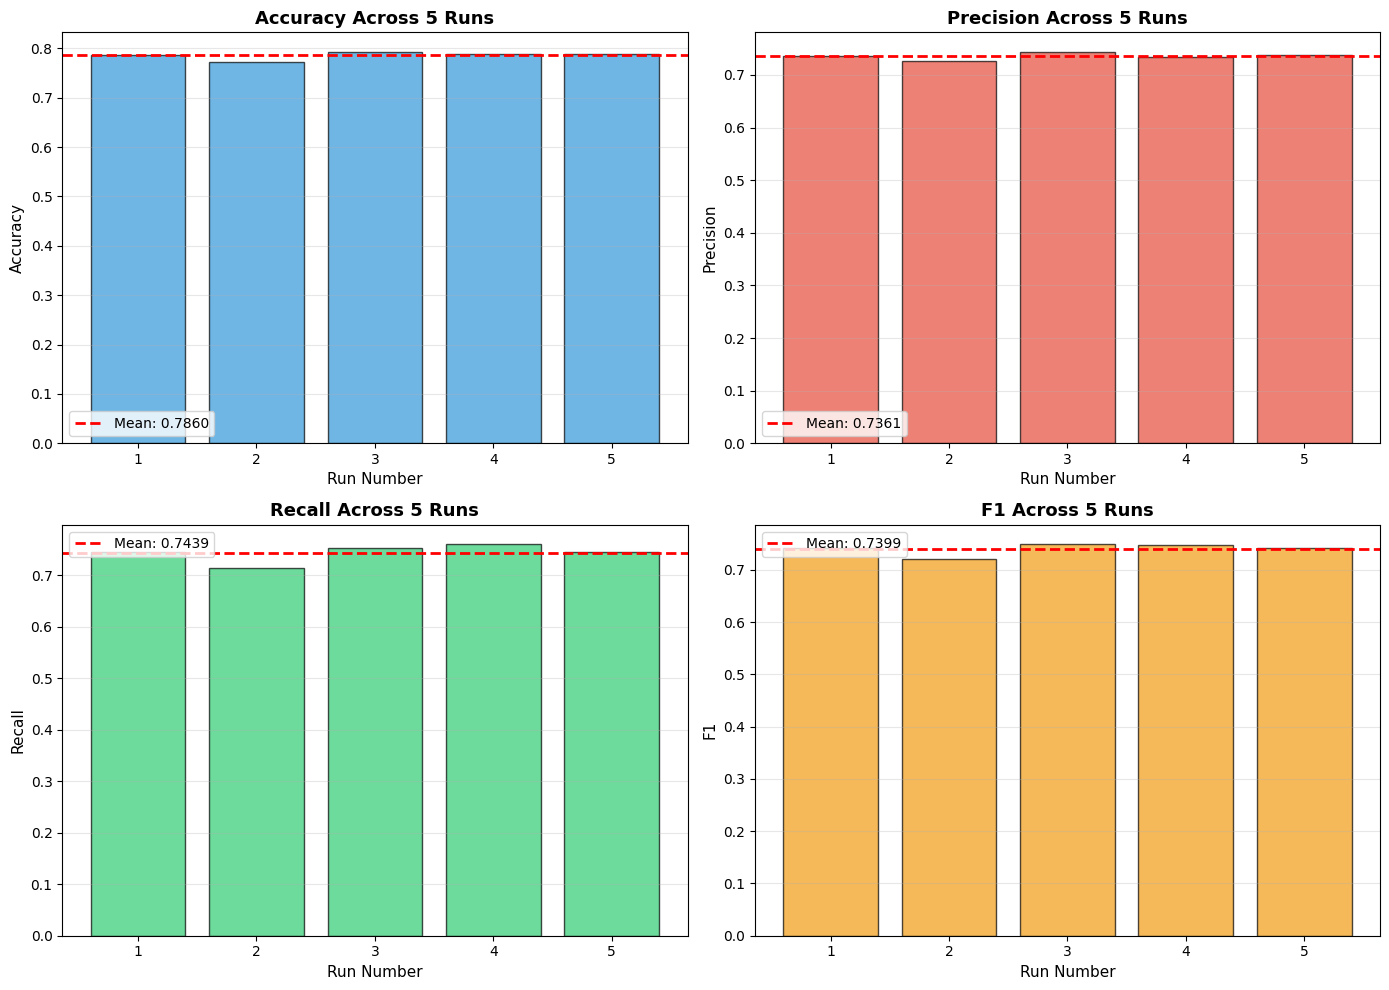

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    values = results[metric]
    
    # Bar plot
    ax.bar(range(1, n_runs + 1), values, color=color, alpha=0.7, edgecolor='black')
    
    # Mean line
    mean_val = np.mean(values)
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    
    # Formatting
    ax.set_xlabel('Run Number', fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f'{metric.capitalize()} Across {n_runs} Runs', fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_runs + 1))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Error Analysis

Examining misclassified examples to understand model limitations and potential improvements.

In [ ]:
val_df = pd.DataFrame({
    'text': X_val,
    'true_label': y_val,
    'predicted_label': y_pred,
    'probability': y_pred_proba,
    'correct': y_val == y_pred
})

# False Positives (predicted disaster, actually non-disaster)
false_positives = val_df[(val_df['true_label'] == 0) & (val_df['predicted_label'] == 1)]
print(f"FALSE POSITIVES ({len(false_positives)} examples)")
for idx, (_, row) in enumerate(false_positives.head(10).iterrows(), 1):
    print(f"{idx}. Text: {row['text']}")
    print(f"   Probability: {row['probability']:.4f}\n")

# False Negatives (predicted non-disaster, actually disaster)
false_negatives = val_df[(val_df['true_label'] == 1) & (val_df['predicted_label'] == 0)]
print(f"FALSE NEGATIVES ({len(false_negatives)} examples)")
for idx, (_, row) in enumerate(false_negatives.head(10).iterrows(), 1):
    print(f"{idx}. Text: {row['text']}")
    print(f"   Probability: {row['probability']:.4f}\n")

FALSE POSITIVES (150 examples)
1. Text: Patience Jonathan On The Move To Hijack APC In BayelsaState
   Probability: 0.6574

2. Text: 'Cooler than Freddie Jackson sippin' a milkshake in a snowstorm'
   Probability: 0.5612

3. Text: i could die by falling in a sinkhole and i'd still be blamed for it
   Probability: 0.6094

4. Text: Sitting in a cafe enjoying a bite and cramming for my meeting during my whirlwind 14-hours in NYC!
   Probability: 0.6469

5. Text: besides your nasty thunderstorm or snowstorm nah. Can't say that I have.
   Probability: 0.6033

6. Text: Arsonists being blamed for a blaze at a plastics recycling business in Adelaide | reports. #7NewsAdl
   Probability: 0.5264

7. Text: Tips so that finding the customers ego drought: dqSVYusY
   Probability: 0.6271

8. Text: Mere sight of a gun makes police and public more aggressive experts say
   Probability: 0.6115

9. Text: Why Some Traffic Is Freezing Cold And Some Blazing Hot And How To Heat Up Some Of Your Traffic
   Pro

### 7.1 Confidence Analysis

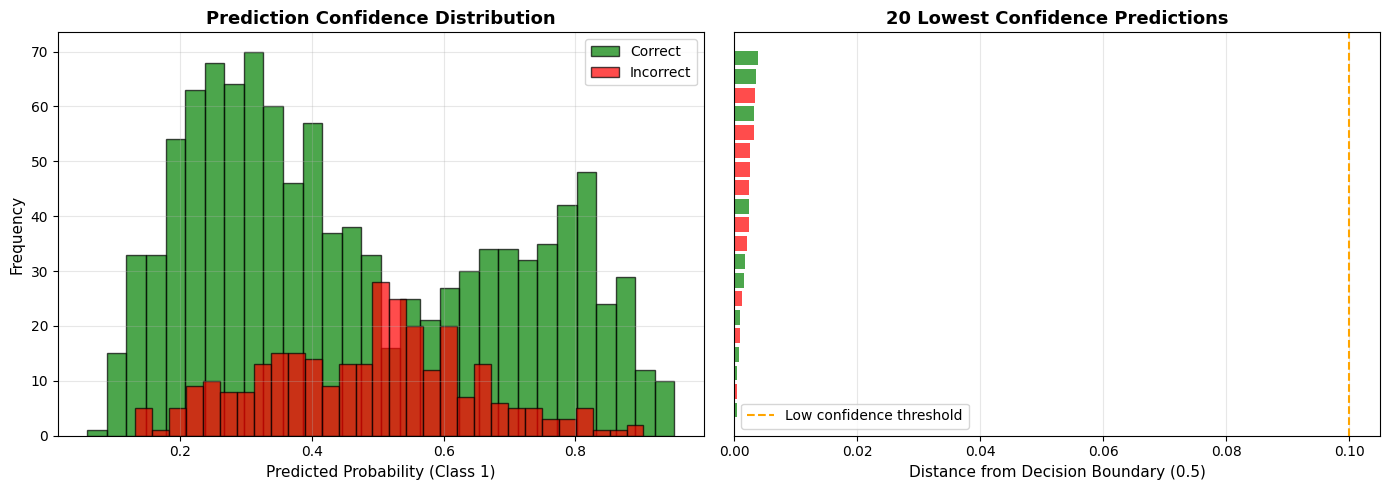


Mean confidence (correct): 0.4648
Mean confidence (incorrect): 0.4830
Low confidence predictions (< 0.6 or > 0.4): 342


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

correct_probs = val_df[val_df['correct']]['probability']
incorrect_probs = val_df[~val_df['correct']]['probability']

axes[0].hist(correct_probs, bins=30, alpha=0.7, color='green', label='Correct', edgecolor='black')
axes[0].hist(incorrect_probs, bins=30, alpha=0.7, color='red', label='Incorrect', edgecolor='black')
axes[0].set_xlabel('Predicted Probability (Class 1)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Low confidence predictions
val_df['confidence'] = np.abs(val_df['probability'] - 0.5)
low_confidence = val_df.nsmallest(20, 'confidence')

colors_list = ['green' if c else 'red' for c in low_confidence['correct']]
axes[1].barh(range(len(low_confidence)), low_confidence['confidence'], color=colors_list, alpha=0.7)
axes[1].set_xlabel('Distance from Decision Boundary (0.5)', fontsize=11)
axes[1].set_title('20 Lowest Confidence Predictions', fontsize=13, fontweight='bold')
axes[1].set_yticks([])
axes[1].axvline(x=0.1, color='orange', linestyle='--', label='Low confidence threshold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean confidence (correct): {correct_probs.mean():.4f}")
print(f"Mean confidence (incorrect): {incorrect_probs.mean():.4f}")
print(f"Low confidence predictions (< 0.6 or > 0.4): {len(val_df[(val_df['probability'] > 0.4) & (val_df['probability'] < 0.6)])}")

## 8. Save Predictions

Save validation predictions for further analysis or comparison with other models.

In [ ]:
predictions_df = pd.DataFrame({
    'text': X_val,
    'true_label': y_val,
    'predicted_label': y_pred,
    'probability_class_1': y_pred_proba,
    'correct': y_val == y_pred
})

predictions_df.to_csv('tfidf_lr_predictions.csv', index=False)
print("Predictions saved to 'tfidf_lr_predictions.csv'")
print(f"Total predictions: {len(predictions_df)}")
print(f"Correct predictions: {predictions_df['correct'].sum()}")
print(f"Incorrect predictions: {(~predictions_df['correct']).sum()}")

Predictions saved to 'tfidf_lr_predictions.csv'
Total predictions: 1385
Correct predictions: 1091
Incorrect predictions: 294


## 9. Summary and Conclusions

### Model Performance
The TF-IDF + Logistic Regression model demonstrates strong performance on the disaster tweet classification task with consistent results across multiple training runs.

### Key Findings
1. **TF-IDF Vectorization** effectively captures the semantic importance of terms, with disaster-related keywords receiving high weights
2. **Logistic Regression** learns interpretable linear decision boundaries, with coefficients directly indicating feature importance
3. **Consistency** across multiple runs suggests the model is stable and not sensitive to random initialization
4. **Error Analysis** reveals challenging cases where context and figurative language lead to misclassifications

### Model Characteristics
- **Strengths**: Fast training, interpretable, works well with high-dimensional sparse data
- **Limitations**: Cannot capture complex semantic relationships or context (e.g., sarcasm, metaphors)
- **Computational Efficiency**: Very low training and inference time compared to transformer models


## References

1. Spärck Jones, K. (1972). "A statistical interpretation of term specificity and its application in retrieval." *Journal of Documentation*, 28(1), 11-21.

2. Das, M., & Chakraborty, S. (2023). "A Comparative Study on TF-IDF feature Weighting Method and its Analysis using Unstructured Dataset." *arXiv preprint arXiv:2308.04037*.

3. Kaggle NLP Getting Started Competition: https://www.kaggle.com/competitions/nlp-getting-started

4. Alhammadi, H. (2022). "Using Machine Learning in Disaster Tweets Classification." Master's Thesis, Rochester Institute of Technology.

5. Tennessee Tech (2020). "NLP Disaster Tweets Classification." Proceedings of Student Research and Creative Inquiry Day.